In [1]:
# ============ HÜCRE 1 — Kurulum + Tohum + Otomatik Klasörler + Loader ============
import sys
sys.path.append('F:/CancerDataClassification/src')

import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import importlib, random, json, csv

import dataset
importlib.reload(dataset)
from dataset import HAMDataset, get_transforms

from models import pretrained_models
importlib.reload(pretrained_models)
from models.pretrained_models import get_model, count_parameters

import train as train_module
importlib.reload(train_module)
from train import train_model

from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42   # <-- HER KOŞUDA SADECE BURAYI DEĞİŞTİR: 13, sonra 21, sonra 42
set_seed(SEED)

BASE = Path('F:/CancerDataClassification')
DATA = BASE / 'data'
MODELS_DIR = BASE / 'models/binary'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SEED_DIR = BASE / f'results/binary/seed{SEED}'
FIG = SEED_DIR / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

def mpath(name):
    return str(MODELS_DIR / f'{name}_binary_seed{SEED}.pth')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bin_names = ['benign', 'malignant']
val_results_bin = {}
test_results_bin = {}

# Loader (224, batch 32, augmentation açık) — tüm modeller aynısını kullanır
IMAGE_SIZE = 224
BATCH_SIZE = 32
train_dataset_binary = HAMDataset(
    csv_path=str(DATA / 'binary_train_balanced.csv'), task='binary',
    transform=get_transforms(image_size=IMAGE_SIZE, mode='train', use_augmentation=True))
val_dataset_binary = HAMDataset(
    csv_path=str(DATA / 'split_val.csv'), task='binary',
    transform=get_transforms(image_size=IMAGE_SIZE, mode='val'))
train_loader_binary = DataLoader(train_dataset_binary, batch_size=BATCH_SIZE,
                                 shuffle=True, num_workers=0, pin_memory=True)
val_loader_binary = DataLoader(val_dataset_binary, batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=0, pin_memory=True)

print(f"Tohum: {SEED} | Device: {device}")
print(f"Sonuçlar buraya: {SEED_DIR}")
print(f"Train: {len(train_dataset_binary)} | Val: {len(val_dataset_binary)}")

C:\Users\Lada\.conda\envs\cancer_cls\lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()


Tohum: 42 | Device: cuda
Sonuçlar buraya: F:\CancerDataClassification\results\binary\seed42
Train: 2712 | Val: 1532


# ResNet50 model

In [2]:
# ============ HÜCRE 2 — ResNet50 Eğitim ============
set_seed(SEED)
model = get_model('resnet50', num_classes=2, pretrained=True)
print(f"ResNet50 | Parametreler: {count_parameters(model):,}")

history_resnet = train_model(
    model=model, train_loader=train_loader_binary, val_loader=val_loader_binary,
    epochs=25, max_lr=0.001, save_path=mpath('resnet50'),
    device=device, pct_start=0.3)

ResNet50 | Parametreler: 23,512,130
TRAINING BAŞLADI
Epochs: 25
Max LR: 0.001
Total steps: 2125
Device: cuda
Save path: F:\CancerDataClassification\models\binary\resnet50_binary_seed42.pth


Epoch   1/25 | Train Loss: 0.6917 Acc: 52.80% | Val Loss: 0.6498 Acc: 67.36% | LR: 0.00008 | Time: 77.7s
   💾 Best model saved! Val Acc: 67.36%


Epoch   2/25 | Train Loss: 0.6420 Acc: 67.88% | Val Loss: 0.5646 Acc: 76.50% | LR: 0.00020 | Time: 76.1s
   💾 Best model saved! Val Acc: 76.50%


Epoch   3/25 | Train Loss: 0.5809 Acc: 72.38% | Val Loss: 0.5015 Acc: 74.80% | LR: 0.00037 | Time: 79.2s


Epoch   4/25 | Train Loss: 0.5255 Acc: 74.48% | Val Loss: 0.4796 Acc: 73.63% | LR: 0.00057 | Time: 76.9s


...

Epoch  21/25 | Train Loss: 0.3463 Acc: 83.81% | Val Loss: 0.3669 Acc: 82.64% | LR: 0.00012 | Time: 76.3s


Epoch  22/25 | Train Loss: 0.3433 Acc: 84.37% | Val Loss: 0.3862 Acc: 81.66% | LR: 0.00007 | Time: 77.4s


Epoch  23/25 | Train Loss: 0.3336 Acc: 85.29% | Val Loss: 0.3810 Acc: 81.92% | LR: 0.00003 | Time: 77.4s


Epoch  24/25 | Train Loss: 0.3322 Acc: 84.73% | Val Loss: 0.3959 Acc: 81.14% | LR: 0.00001 | Time: 76.2s


Epoch  25/25 | Train Loss: 0.3333 Acc: 84.92% | Val Loss: 0.3772 Acc: 82.31% | LR: 0.00000 | Time: 79.3s

EĞİTİM BİTTİ - Toplam süre: 32.3 dakika
En iyi Val Acc: 82.77%
Model kaydedildi: F:\CancerDataClassification\models\binary\resnet50_binary_seed42.pth


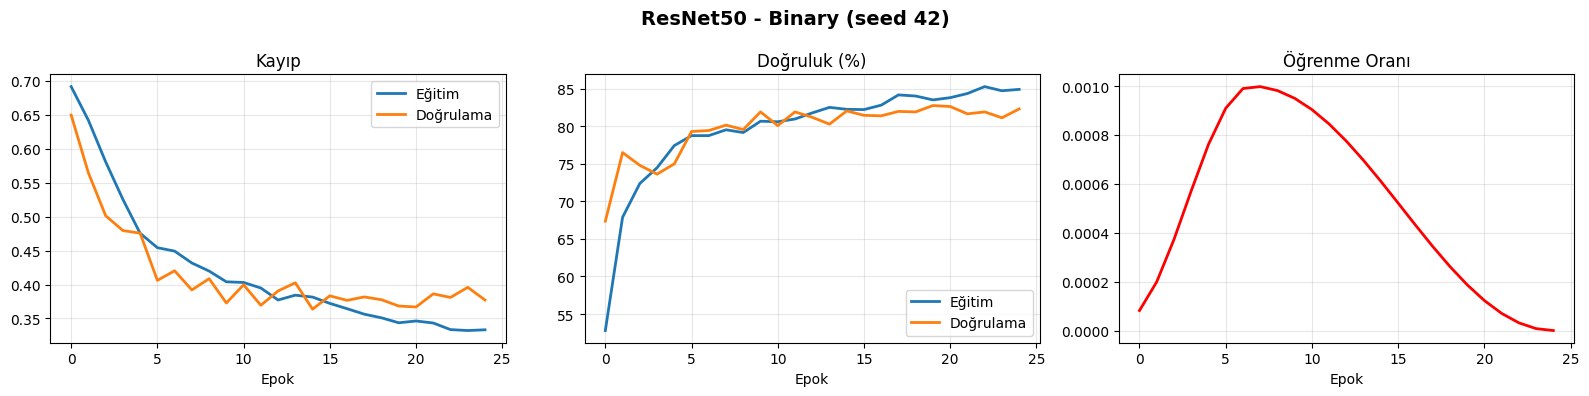

In [3]:
# ============ HÜCRE 3 — ResNet50 Eğitim Grafiği ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_resnet['train_loss'], label='Eğitim', linewidth=2)
axes[0].plot(history_resnet['val_loss'], label='Doğrulama', linewidth=2)
axes[0].set_title('Kayıp'); axes[0].set_xlabel('Epok'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history_resnet['train_acc']], label='Eğitim', linewidth=2)
axes[1].plot([a*100 for a in history_resnet['val_acc']], label='Doğrulama', linewidth=2)
axes[1].set_title('Doğruluk (%)'); axes[1].set_xlabel('Epok'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history_resnet['lrs'], color='red', linewidth=2)
axes[2].set_title('Öğrenme Oranı'); axes[2].set_xlabel('Epok'); axes[2].grid(alpha=0.3)
plt.suptitle(f'ResNet50 - Binary (seed {SEED})', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(FIG / 'resnet50_training.png', dpi=150); plt.show()

ResNet50 (val): {'acc': 82.76762402088774, 'macro_f1': 77.29758857604743, 'auc': 0.916836431542314}
              precision    recall  f1-score   support

      benign      0.953     0.825     0.884      1224
   malignant      0.547     0.838     0.662       308

    accuracy                          0.828      1532
   macro avg      0.750     0.831     0.773      1532
weighted avg      0.871     0.828     0.840      1532



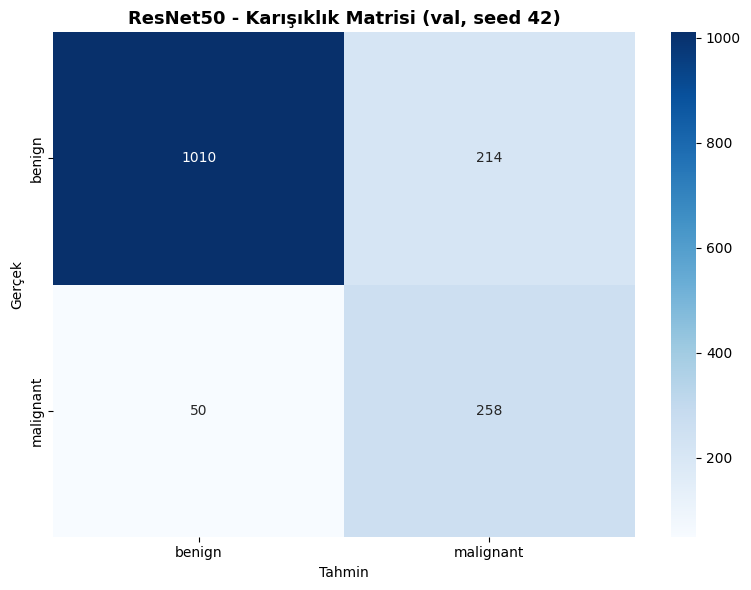

In [4]:
# ============ HÜCRE 4 — ResNet50 Değerlendirme (val) ============
checkpoint = torch.load(mpath('resnet50'), map_location=device, weights_only=False)
model = get_model('resnet50', num_classes=2, pretrained=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in val_loader_binary:
        outputs = model(imgs.to(device))
        all_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

val_results_bin['ResNet50'] = {
    'acc': accuracy_score(all_labels, all_preds)*100,
    'macro_f1': f1_score(all_labels, all_preds, average='macro')*100,
    'auc': roc_auc_score(all_labels, all_probs)}
print("ResNet50 (val):", val_results_bin['ResNet50'])
print(classification_report(all_labels, all_preds, target_names=bin_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=bin_names, yticklabels=bin_names, ax=ax)
ax.set_title(f'ResNet50 - Karışıklık Matrisi (val, seed {SEED})', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout(); plt.savefig(FIG / 'resnet50_cm.png', dpi=150); plt.show()

# DenseNet121

In [5]:
# ============ HÜCRE 5 — DenseNet121 Eğitim ============
set_seed(SEED)
model = get_model('densenet121', num_classes=2, pretrained=True)
print(f"DenseNet121 | Parametreler: {count_parameters(model):,}")

history_densenet_binary = train_model(
    model=model, train_loader=train_loader_binary, val_loader=val_loader_binary,
    epochs=25, max_lr=0.0008, save_path=mpath('densenet121'),
    device=device, pct_start=0.3)

DenseNet121 | Parametreler: 6,955,906
TRAINING BAŞLADI
Epochs: 25
Max LR: 0.0008
Total steps: 2125
Device: cuda
Save path: F:\CancerDataClassification\models\binary\densenet121_binary_seed42.pth


Epoch   1/25 | Train Loss: 0.6688 Acc: 58.52% | Val Loss: 0.5983 Acc: 68.41% | LR: 0.00007 | Time: 83.9s
   💾 Best model saved! Val Acc: 68.41%


Epoch   2/25 | Train Loss: 0.5377 Acc: 73.38% | Val Loss: 0.4895 Acc: 72.85% | LR: 0.00016 | Time: 79.4s
   💾 Best model saved! Val Acc: 72.85%


Epoch   3/25 | Train Loss: 0.4872 Acc: 76.70% | Val Loss: 0.4822 Acc: 74.48% | LR: 0.00030 | Time: 78.8s
   💾 Best model saved! Val Acc: 74.48%


Epoch   4/25 | Train Loss: 0.4402 Acc: 78.69% | Val Loss: 0.4501 Acc: 76.76% | LR: 0.00046 | Time: 79.1s
   💾 Best model saved! Val Acc: 76.76%


...

Epoch  21/25 | Train Loss: 0.2580 Acc: 88.72% | Val Loss: 0.4012 Acc: 82.96% | LR: 0.00010 | Time: 78.8s


Epoch  22/25 | Train Loss: 0.2639 Acc: 89.42% | Val Loss: 0.4070 Acc: 83.03% | LR: 0.00006 | Time: 79.4s


Epoch  23/25 | Train Loss: 0.2417 Acc: 90.19% | Val Loss: 0.3520 Acc: 84.33% | LR: 0.00003 | Time: 81.6s


Epoch  24/25 | Train Loss: 0.2385 Acc: 89.68% | Val Loss: 0.4256 Acc: 82.25% | LR: 0.00001 | Time: 79.9s


Epoch  25/25 | Train Loss: 0.2475 Acc: 89.64% | Val Loss: 0.3617 Acc: 84.46% | LR: 0.00000 | Time: 79.4s

EĞİTİM BİTTİ - Toplam süre: 33.6 dakika
En iyi Val Acc: 85.90%
Model kaydedildi: F:\CancerDataClassification\models\binary\densenet121_binary_seed42.pth


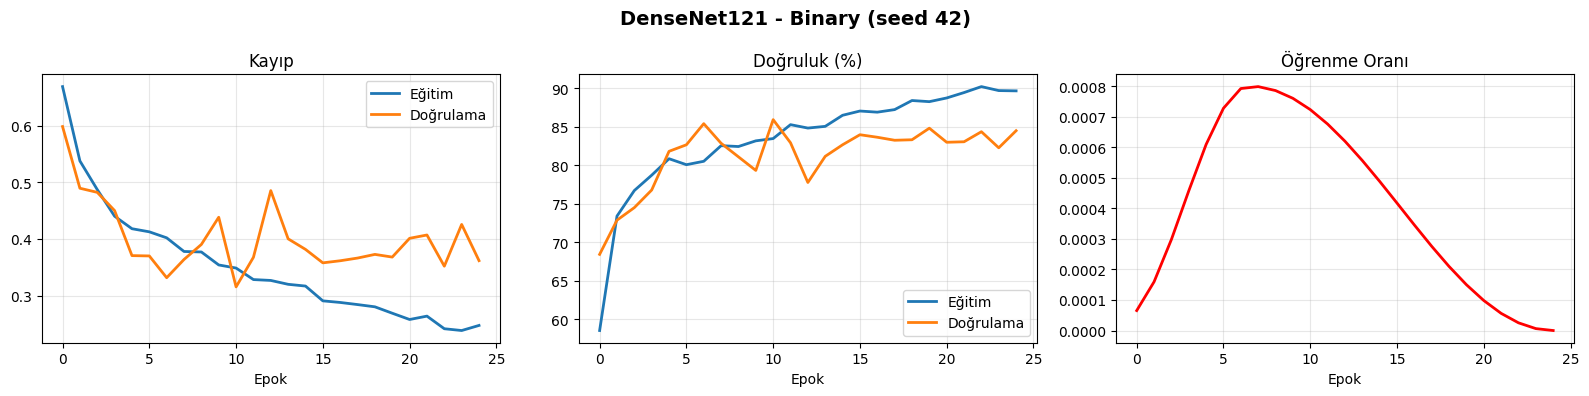

In [6]:
# ============ HÜCRE 6 — DenseNet121 Eğitim Grafiği ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_densenet_binary['train_loss'], label='Eğitim', linewidth=2)
axes[0].plot(history_densenet_binary['val_loss'], label='Doğrulama', linewidth=2)
axes[0].set_title('Kayıp'); axes[0].set_xlabel('Epok'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history_densenet_binary['train_acc']], label='Eğitim', linewidth=2)
axes[1].plot([a*100 for a in history_densenet_binary['val_acc']], label='Doğrulama', linewidth=2)
axes[1].set_title('Doğruluk (%)'); axes[1].set_xlabel('Epok'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history_densenet_binary['lrs'], color='red', linewidth=2)
axes[2].set_title('Öğrenme Oranı'); axes[2].set_xlabel('Epok'); axes[2].grid(alpha=0.3)
plt.suptitle(f'DenseNet121 - Binary (seed {SEED})', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(FIG / 'densenet121_training.png', dpi=150); plt.show()

DenseNet121 (val): {'acc': 85.90078328981723, 'macro_f1': 80.16172196483555, 'auc': 0.9225845641286816}
              precision    recall  f1-score   support

      benign      0.945     0.874     0.908      1224
   malignant      0.615     0.799     0.695       308

    accuracy                          0.859      1532
   macro avg      0.780     0.836     0.802      1532
weighted avg      0.879     0.859     0.865      1532



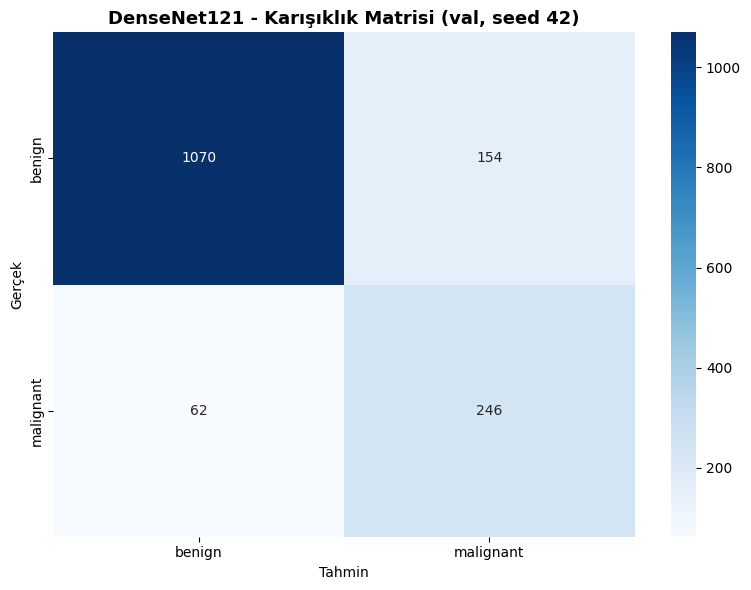

In [7]:
# ============ HÜCRE 7 — DenseNet121 Değerlendirme (val) ============
checkpoint = torch.load(mpath('densenet121'), map_location=device, weights_only=False)
model = get_model('densenet121', num_classes=2, pretrained=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in val_loader_binary:
        outputs = model(imgs.to(device))
        all_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

val_results_bin['DenseNet121'] = {
    'acc': accuracy_score(all_labels, all_preds)*100,
    'macro_f1': f1_score(all_labels, all_preds, average='macro')*100,
    'auc': roc_auc_score(all_labels, all_probs)}
print("DenseNet121 (val):", val_results_bin['DenseNet121'])
print(classification_report(all_labels, all_preds, target_names=bin_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=bin_names, yticklabels=bin_names, ax=ax)
ax.set_title(f'DenseNet121 - Karışıklık Matrisi (val, seed {SEED})', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout(); plt.savefig(FIG / 'densenet121_cm.png', dpi=150); plt.show()

# ConvNeXt-Tiny

In [8]:
# ============ HÜCRE 8 — ConvNeXt-Tiny Eğitim ============
set_seed(SEED)
model = get_model('convnext_tiny', num_classes=2, pretrained=True)
print(f"ConvNeXt-Tiny | Parametreler: {count_parameters(model):,}")

history_convnext_binary = train_model(
    model=model, train_loader=train_loader_binary, val_loader=val_loader_binary,
    epochs=25, max_lr=0.0005, save_path=mpath('convnext_tiny'),
    device=device, pct_start=0.3)

ConvNeXt-Tiny | Parametreler: 27,821,666
TRAINING BAŞLADI
Epochs: 25
Max LR: 0.0005
Total steps: 2125
Device: cuda
Save path: F:\CancerDataClassification\models\binary\convnext_tiny_binary_seed42.pth


Epoch   1/25 | Train Loss: 0.6564 Acc: 60.84% | Val Loss: 0.5441 Acc: 75.65% | LR: 0.00004 | Time: 91.8s
   💾 Best model saved! Val Acc: 75.65%


Epoch   2/25 | Train Loss: 0.5305 Acc: 74.08% | Val Loss: 0.4750 Acc: 75.59% | LR: 0.00010 | Time: 92.1s


Epoch   3/25 | Train Loss: 0.4662 Acc: 77.62% | Val Loss: 0.4773 Acc: 74.74% | LR: 0.00019 | Time: 91.1s


Epoch   4/25 | Train Loss: 0.4651 Acc: 77.06% | Val Loss: 0.5117 Acc: 72.65% | LR: 0.00029 | Time: 91.0s


...

Epoch  21/25 | Train Loss: 0.3062 Acc: 86.32% | Val Loss: 0.3769 Acc: 82.83% | LR: 0.00006 | Time: 92.6s


Epoch  22/25 | Train Loss: 0.2976 Acc: 86.06% | Val Loss: 0.3191 Acc: 86.23% | LR: 0.00004 | Time: 91.5s
   💾 Best model saved! Val Acc: 86.23%


Epoch  23/25 | Train Loss: 0.3027 Acc: 86.17% | Val Loss: 0.4122 Acc: 81.46% | LR: 0.00002 | Time: 91.0s


Epoch  24/25 | Train Loss: 0.2967 Acc: 86.28% | Val Loss: 0.3848 Acc: 82.64% | LR: 0.00000 | Time: 92.0s


Epoch  25/25 | Train Loss: 0.2828 Acc: 86.91% | Val Loss: 0.3832 Acc: 82.64% | LR: 0.00000 | Time: 92.6s

EĞİTİM BİTTİ - Toplam süre: 38.3 dakika
En iyi Val Acc: 86.23%
Model kaydedildi: F:\CancerDataClassification\models\binary\convnext_tiny_binary_seed42.pth


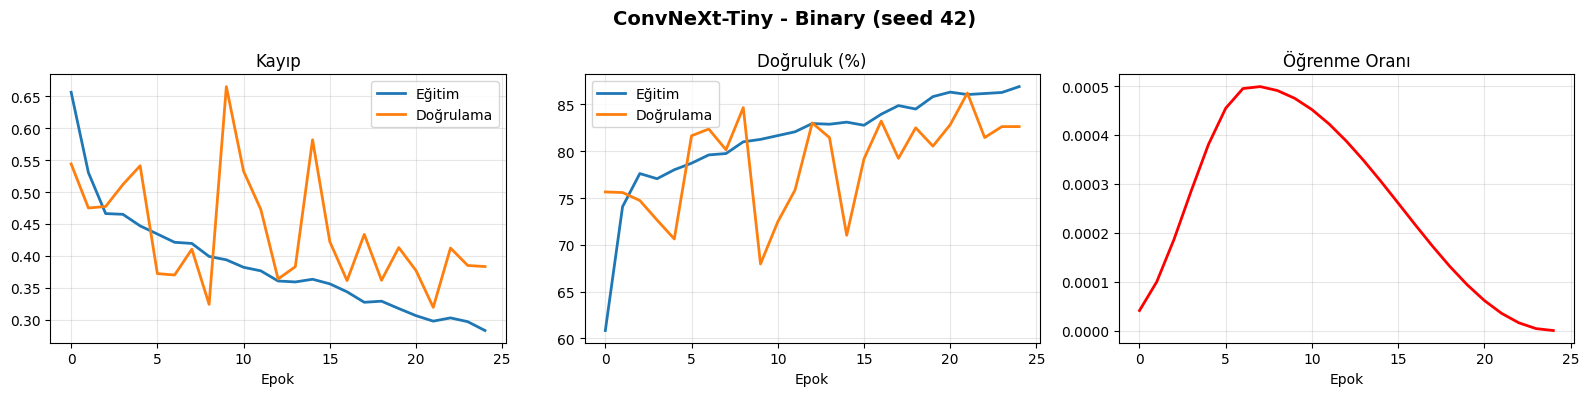

In [9]:
# ============ HÜCRE 9 — ConvNeXt-Tiny Eğitim Grafiği ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_convnext_binary['train_loss'], label='Eğitim', linewidth=2)
axes[0].plot(history_convnext_binary['val_loss'], label='Doğrulama', linewidth=2)
axes[0].set_title('Kayıp'); axes[0].set_xlabel('Epok'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history_convnext_binary['train_acc']], label='Eğitim', linewidth=2)
axes[1].plot([a*100 for a in history_convnext_binary['val_acc']], label='Doğrulama', linewidth=2)
axes[1].set_title('Doğruluk (%)'); axes[1].set_xlabel('Epok'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history_convnext_binary['lrs'], color='red', linewidth=2)
axes[2].set_title('Öğrenme Oranı'); axes[2].set_xlabel('Epok'); axes[2].grid(alpha=0.3)
plt.suptitle(f'ConvNeXt-Tiny - Binary (seed {SEED})', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(FIG / 'convnext_tiny_training.png', dpi=150); plt.show()

ConvNeXt-Tiny (val): {'acc': 86.22715404699738, 'macro_f1': 80.52444205055721, 'auc': 0.9233166751549104}
              precision    recall  f1-score   support

      benign      0.945     0.878     0.911      1224
   malignant      0.623     0.799     0.700       308

    accuracy                          0.862      1532
   macro avg      0.784     0.838     0.805      1532
weighted avg      0.881     0.862     0.868      1532



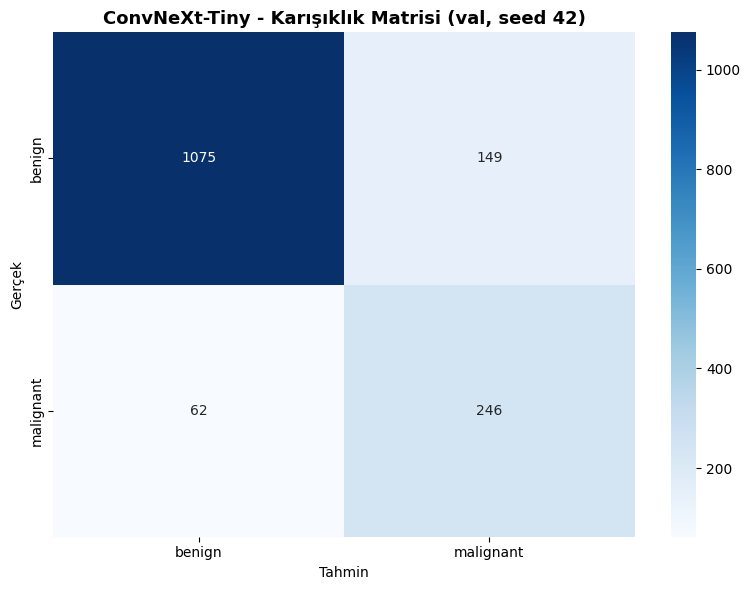

In [10]:
# ============ HÜCRE 10 — ConvNeXt-Tiny Değerlendirme (val) ============
checkpoint = torch.load(mpath('convnext_tiny'), map_location=device, weights_only=False)
model = get_model('convnext_tiny', num_classes=2, pretrained=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in val_loader_binary:
        outputs = model(imgs.to(device))
        all_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

val_results_bin['ConvNeXt-Tiny'] = {
    'acc': accuracy_score(all_labels, all_preds)*100,
    'macro_f1': f1_score(all_labels, all_preds, average='macro')*100,
    'auc': roc_auc_score(all_labels, all_probs)}
print("ConvNeXt-Tiny (val):", val_results_bin['ConvNeXt-Tiny'])
print(classification_report(all_labels, all_preds, target_names=bin_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=bin_names, yticklabels=bin_names, ax=ax)
ax.set_title(f'ConvNeXt-Tiny - Karışıklık Matrisi (val, seed {SEED})', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout(); plt.savefig(FIG / 'convnext_tiny_cm.png', dpi=150); plt.show()

# EfficientNet-B3 Binary Eğitimi

In [11]:
# ============ HÜCRE 11 — EfficientNet-B3 Eğitim ============
set_seed(SEED)
model = get_model('efficientnet_b3', num_classes=2, pretrained=True)
print(f"EfficientNet-B3 | Parametreler: {count_parameters(model):,}")

history_b3_binary = train_model(
    model=model, train_loader=train_loader_binary, val_loader=val_loader_binary,
    epochs=25, max_lr=0.0008, save_path=mpath('efficientnet_b3'),
    device=device, pct_start=0.3)

EfficientNet-B3 | Parametreler: 10,699,306
TRAINING BAŞLADI
Epochs: 25
Max LR: 0.0008
Total steps: 2125
Device: cuda
Save path: F:\CancerDataClassification\models\binary\efficientnet_b3_binary_seed42.pth


Epoch   1/25 | Train Loss: 0.7040 Acc: 48.27% | Val Loss: 0.6990 Acc: 49.80% | LR: 0.00007 | Time: 79.4s
   💾 Best model saved! Val Acc: 49.80%


Epoch   2/25 | Train Loss: 0.6804 Acc: 56.53% | Val Loss: 0.6351 Acc: 69.71% | LR: 0.00016 | Time: 79.1s
   💾 Best model saved! Val Acc: 69.71%


Epoch   3/25 | Train Loss: 0.6384 Acc: 66.78% | Val Loss: 0.5720 Acc: 76.24% | LR: 0.00030 | Time: 80.9s
   💾 Best model saved! Val Acc: 76.24%


Epoch   4/25 | Train Loss: 0.5928 Acc: 71.31% | Val Loss: 0.5305 Acc: 76.31% | LR: 0.00046 | Time: 79.0s
   💾 Best model saved! Val Acc: 76.31%


...

Epoch  21/25 | Train Loss: 0.4442 Acc: 78.61% | Val Loss: 0.3925 Acc: 80.68% | LR: 0.00010 | Time: 79.7s


Epoch  22/25 | Train Loss: 0.4430 Acc: 78.54% | Val Loss: 0.3956 Acc: 79.57% | LR: 0.00006 | Time: 81.5s


Epoch  23/25 | Train Loss: 0.4398 Acc: 78.58% | Val Loss: 0.3908 Acc: 80.48% | LR: 0.00003 | Time: 78.9s


Epoch  24/25 | Train Loss: 0.4327 Acc: 78.76% | Val Loss: 0.4114 Acc: 78.85% | LR: 0.00001 | Time: 78.6s


Epoch  25/25 | Train Loss: 0.4429 Acc: 77.65% | Val Loss: 0.3950 Acc: 79.37% | LR: 0.00000 | Time: 80.1s

EĞİTİM BİTTİ - Toplam süre: 33.2 dakika
En iyi Val Acc: 81.27%
Model kaydedildi: F:\CancerDataClassification\models\binary\efficientnet_b3_binary_seed42.pth


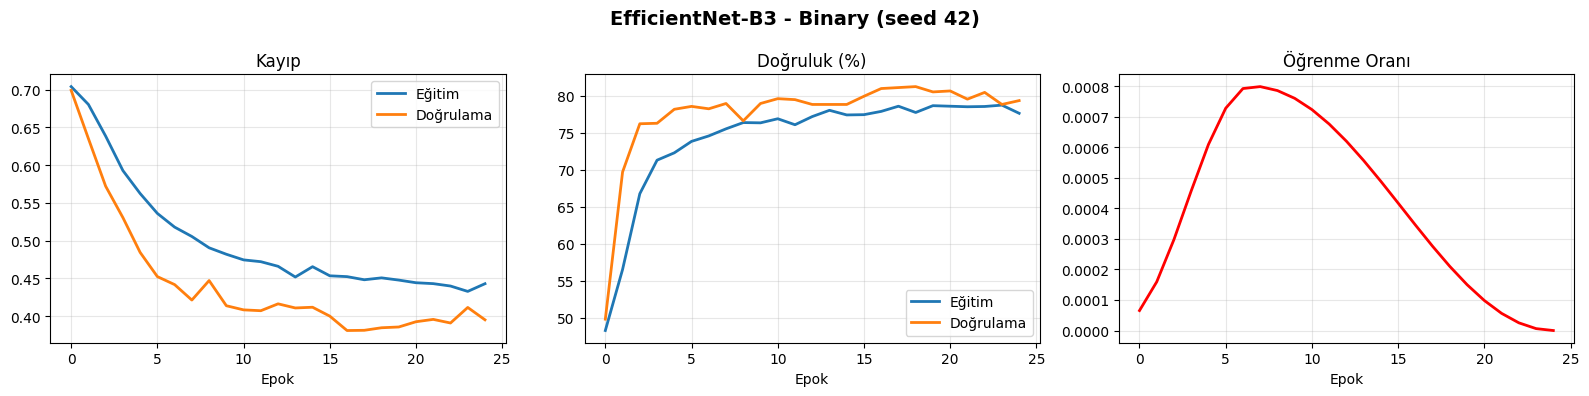

In [12]:
# ============ HÜCRE 12 — EfficientNet-B3 Eğitim Grafiği ============
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history_b3_binary['train_loss'], label='Eğitim', linewidth=2)
axes[0].plot(history_b3_binary['val_loss'], label='Doğrulama', linewidth=2)
axes[0].set_title('Kayıp'); axes[0].set_xlabel('Epok'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in history_b3_binary['train_acc']], label='Eğitim', linewidth=2)
axes[1].plot([a*100 for a in history_b3_binary['val_acc']], label='Doğrulama', linewidth=2)
axes[1].set_title('Doğruluk (%)'); axes[1].set_xlabel('Epok'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history_b3_binary['lrs'], color='red', linewidth=2)
axes[2].set_title('Öğrenme Oranı'); axes[2].set_xlabel('Epok'); axes[2].grid(alpha=0.3)
plt.suptitle(f'EfficientNet-B3 - Binary (seed {SEED})', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(FIG / 'efficientnet_b3_training.png', dpi=150); plt.show()

EfficientNet-B3 (val): {'acc': 81.26631853785901, 'macro_f1': 75.74375380310626, 'auc': 0.8989341948900773}
              precision    recall  f1-score   support

      benign      0.951     0.807     0.873      1224
   malignant      0.521     0.834     0.642       308

    accuracy                          0.813      1532
   macro avg      0.736     0.821     0.757      1532
weighted avg      0.865     0.813     0.827      1532



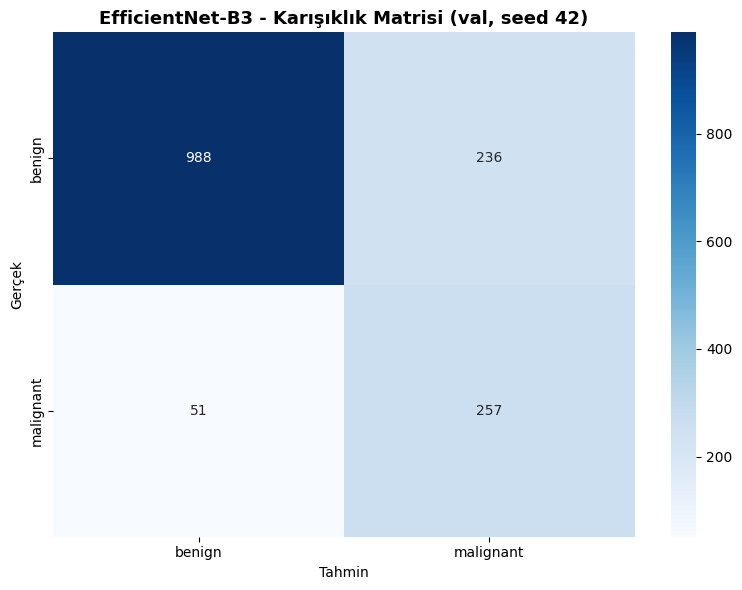

In [13]:
# ============ HÜCRE 13 — EfficientNet-B3 Değerlendirme (val) ============
checkpoint = torch.load(mpath('efficientnet_b3'), map_location=device, weights_only=False)
model = get_model('efficientnet_b3', num_classes=2, pretrained=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in val_loader_binary:
        outputs = model(imgs.to(device))
        all_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

val_results_bin['EfficientNet-B3'] = {
    'acc': accuracy_score(all_labels, all_preds)*100,
    'macro_f1': f1_score(all_labels, all_preds, average='macro')*100,
    'auc': roc_auc_score(all_labels, all_probs)}
print("EfficientNet-B3 (val):", val_results_bin['EfficientNet-B3'])
print(classification_report(all_labels, all_preds, target_names=bin_names, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=bin_names, yticklabels=bin_names, ax=ax)
ax.set_title(f'EfficientNet-B3 - Karışıklık Matrisi (val, seed {SEED})', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
plt.tight_layout(); plt.savefig(FIG / 'efficientnet_b3_cm.png', dpi=150); plt.show()

# gorsellestirme

Test seti: 1502 resim
DenseNet121        Test Doğruluk %84.49 | AUC 0.9037


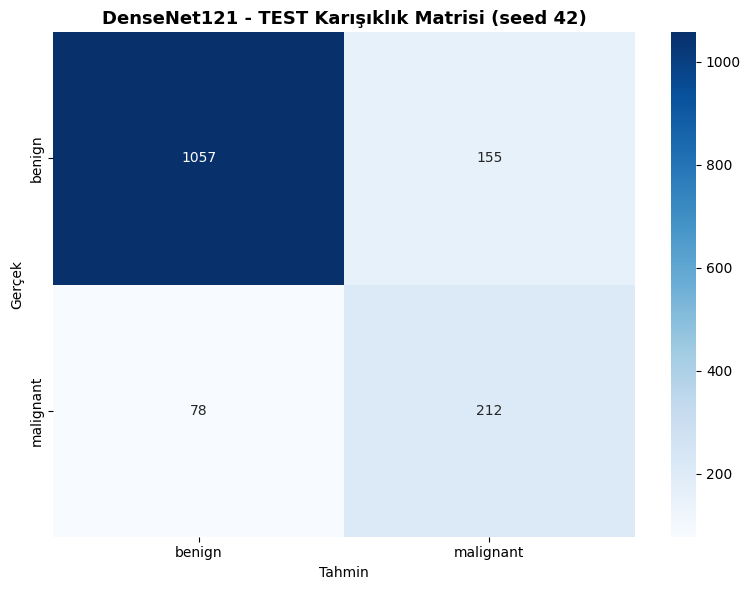

ConvNeXt-Tiny      Test Doğruluk %84.89 | AUC 0.9174


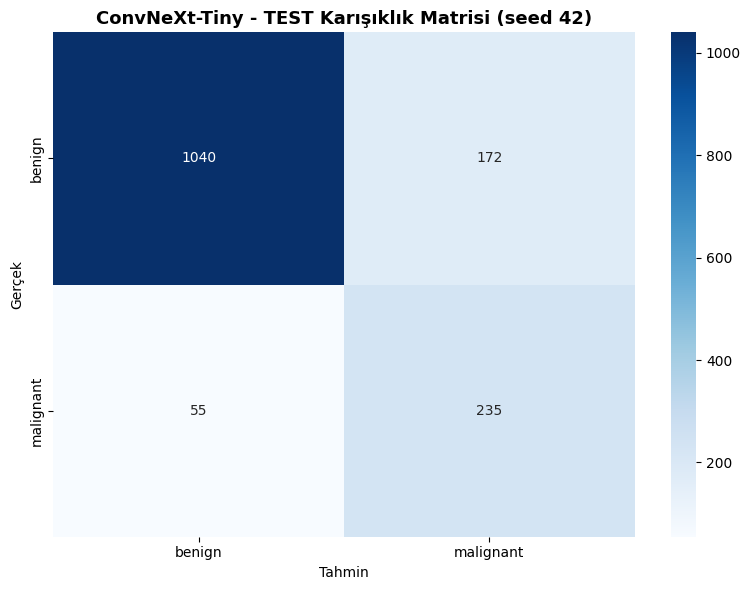

ResNet50           Test Doğruluk %81.36 | AUC 0.8977


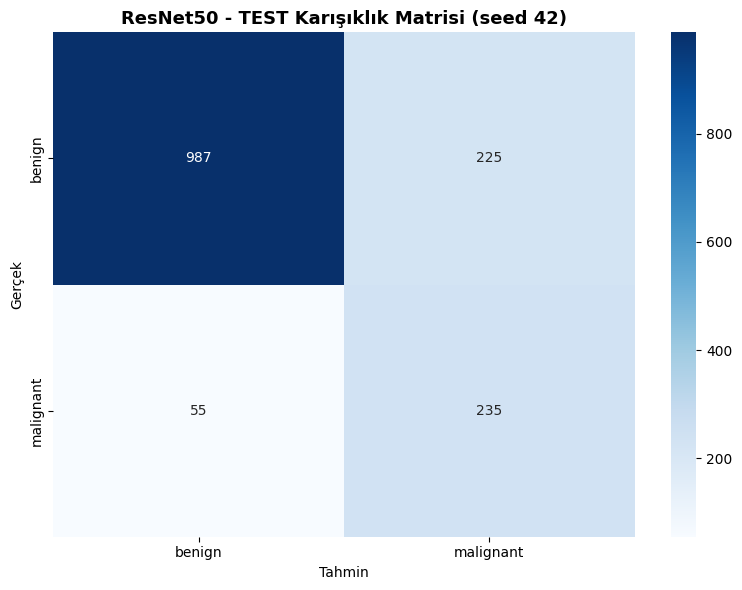

EfficientNet-B3    Test Doğruluk %78.10 | AUC 0.8738


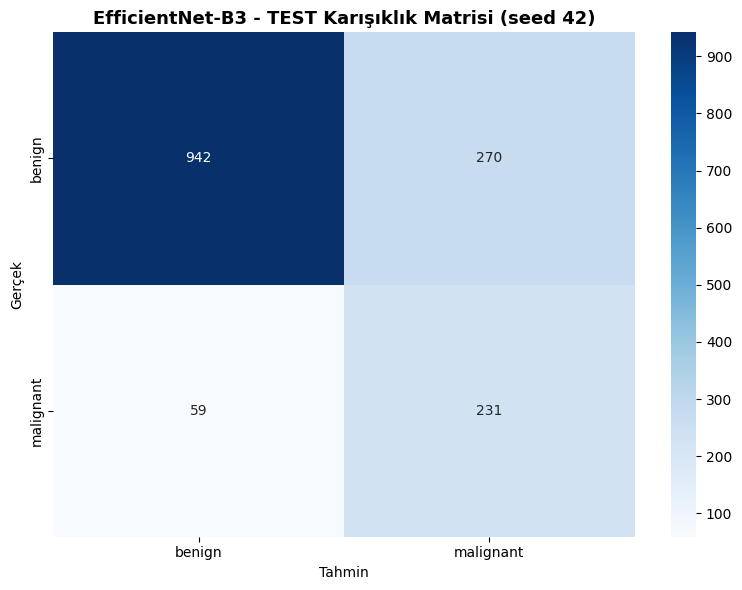


Kaydedildi: F:\CancerDataClassification\results\binary\seed42\results.json


In [14]:
# ============ HÜCRE 14 — TEST Seti (4 model) + TABLOLARI KAYDET ============
test_dataset_binary = HAMDataset(
    csv_path=str(DATA / 'split_test.csv'), task='binary',
    transform=get_transforms(image_size=IMAGE_SIZE, mode='test'))
test_loader_binary = DataLoader(test_dataset_binary, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=0, pin_memory=True)
print(f"Test seti: {len(test_dataset_binary)} resim")

test_models_binary = {
    'DenseNet121':     ('densenet121',     mpath('densenet121')),
    'ConvNeXt-Tiny':   ('convnext_tiny',   mpath('convnext_tiny')),
    'ResNet50':        ('resnet50',        mpath('resnet50')),
    'EfficientNet-B3': ('efficientnet_b3', mpath('efficientnet_b3')),
}

for model_name, (arch, ckpt_path) in test_models_binary.items():
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = get_model(arch, num_classes=2, pretrained=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device).eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader_binary:
            outputs = model(imgs.to(device))
            all_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    test_results_bin[model_name] = {
        'acc': accuracy_score(all_labels, all_preds)*100,
        'macro_f1': f1_score(all_labels, all_preds, average='macro')*100,
        'auc': roc_auc_score(all_labels, all_probs)}
    print(f"{model_name:<18} Test Doğruluk %{test_results_bin[model_name]['acc']:.2f} | AUC {test_results_bin[model_name]['auc']:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=bin_names, yticklabels=bin_names, ax=ax)
    ax.set_title(f'{model_name} - TEST Karışıklık Matrisi (seed {SEED})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
    plt.tight_layout(); plt.savefig(FIG / f'test_{arch}_cm.png', dpi=150); plt.show()

with open(SEED_DIR / 'results.json', 'w') as f:
    json.dump({'seed': SEED, 'val': val_results_bin, 'test': test_results_bin}, f, indent=2)
print(f"\nKaydedildi: {SEED_DIR / 'results.json'}")

Model             Doğruluk          Makro F1          AUC             
--------------------------------------------------------------------
DenseNet121       84.58 ± 0.15     77.87 ± 0.50     0.9089 ± 0.0046
ConvNeXt-Tiny     85.18 ± 0.25     78.49 ± 0.28     0.9071 ± 0.0090
ResNet50          81.25 ± 1.30     74.98 ± 1.28     0.8955 ± 0.0039
EfficientNet-B3   78.21 ± 0.31     71.95 ± 0.34     0.8755 ± 0.0024

Tablo kaydedildi: F:\CancerDataClassification\results\binary\summary\ozet_ort_std.csv


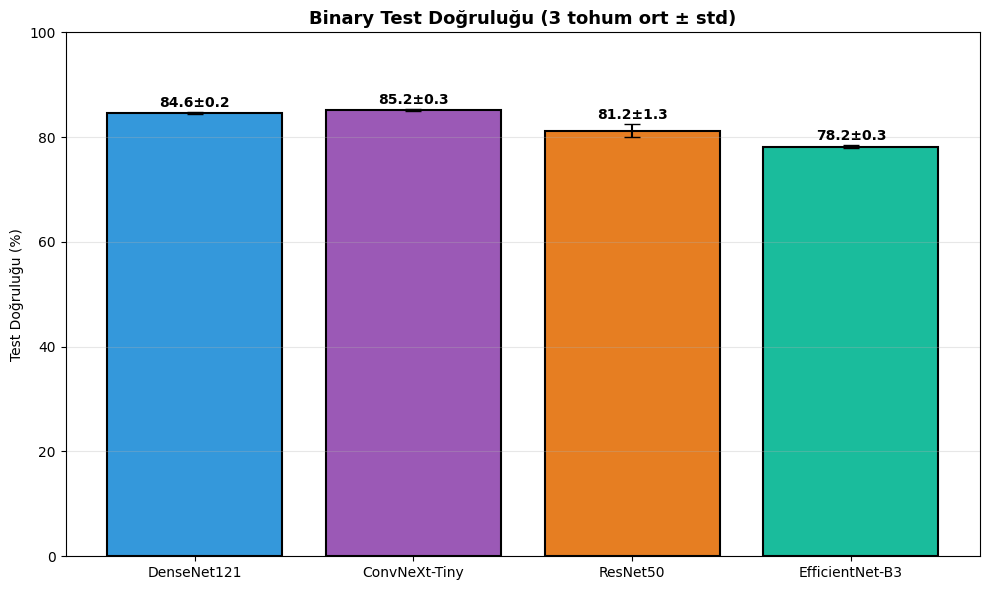

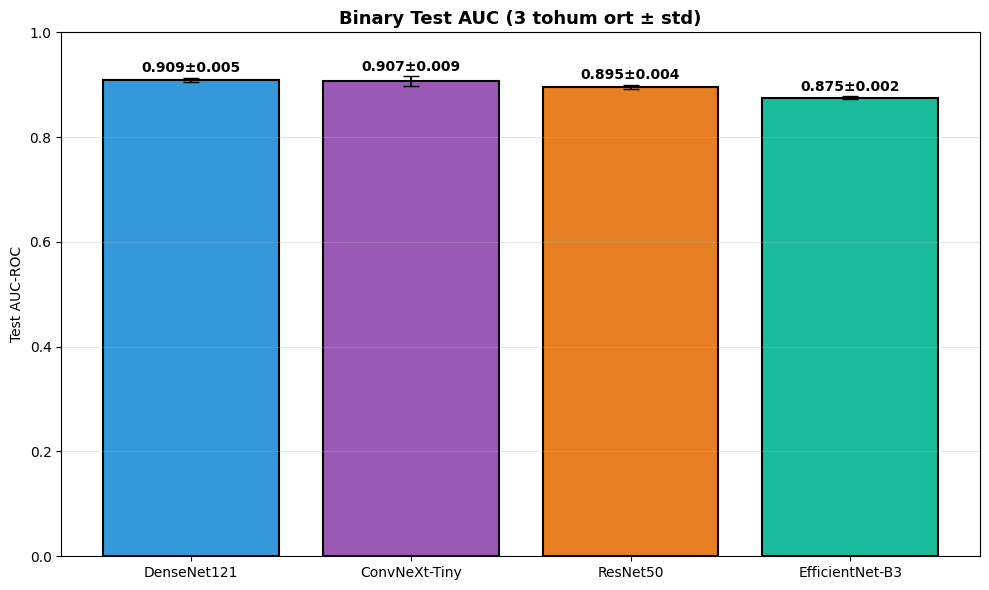

Grafikler kaydedildi: F:\CancerDataClassification\results\binary\summary


In [15]:
# ============ HÜCRE 15 — TÜM TOHUMLARI TOPLA: ort±std tablo + error-bar grafikler ============
# (3 tohum da bitince BİR KEZ çalıştır)
seeds  = [13, 21, 42]
models = ['DenseNet121', 'ConvNeXt-Tiny', 'ResNet50', 'EfficientNet-B3']
metrics = ['acc', 'macro_f1', 'auc']

SUMMARY = BASE / 'results/binary/summary'
SUMMARY.mkdir(parents=True, exist_ok=True)

agg = {m: {k: [] for k in metrics} for m in models}
for s in seeds:
    r = json.load(open(BASE / f'results/binary/seed{s}/results.json'))['test']
    for m in models:
        for k in metrics:
            agg[m][k].append(r[m][k])

# tablo + CSV
print(f"{'Model':<18}{'Doğruluk':<18}{'Makro F1':<18}{'AUC':<16}")
print("-"*68)
rows = []
for m in models:
    row = {'model': m}; line = f"{m:<18}"
    for k in metrics:
        a = np.array(agg[m][k])
        mean, std = a.mean(), a.std(ddof=1)
        row[k+'_mean'] = round(mean, 4); row[k+'_std'] = round(std, 4)
        line += (f"{mean:.2f} ± {std:.2f}     " if k != 'auc' else f"{mean:.4f} ± {std:.4f}")
    print(line); rows.append(row)
with open(SUMMARY / 'ozet_ort_std.csv', 'w', newline='', encoding='utf-8') as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys()); w.writeheader(); w.writerows(rows)
print(f"\nTablo kaydedildi: {SUMMARY / 'ozet_ort_std.csv'}")

colors = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c']
# error-bar: Doğruluk
means = [np.mean(agg[m]['acc']) for m in models]; stds = [np.std(agg[m]['acc'], ddof=1) for m in models]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, means, yerr=stds, capsize=6, color=colors, edgecolor='black', linewidth=1.5)
for b, mn, sd in zip(bars, means, stds):
    ax.text(b.get_x()+b.get_width()/2, mn+sd+0.4, f'{mn:.1f}±{sd:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Test Doğruluğu (%)'); ax.set_ylim(0, 100)
ax.set_title('Binary Test Doğruluğu (3 tohum ort ± std)', fontsize=13, fontweight='bold'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(SUMMARY / 'binary_test_dogruluk_errorbar.png', dpi=150); plt.show()

# error-bar: AUC
means = [np.mean(agg[m]['auc']) for m in models]; stds = [np.std(agg[m]['auc'], ddof=1) for m in models]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, means, yerr=stds, capsize=6, color=colors, edgecolor='black', linewidth=1.5)
for b, mn, sd in zip(bars, means, stds):
    ax.text(b.get_x()+b.get_width()/2, mn+sd+0.005, f'{mn:.3f}±{sd:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Test AUC-ROC'); ax.set_ylim(0, 1.0)
ax.set_title('Binary Test AUC (3 tohum ort ± std)', fontsize=13, fontweight='bold'); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(SUMMARY / 'binary_test_auc_errorbar.png', dpi=150); plt.show()
print(f"Grafikler kaydedildi: {SUMMARY}")

In [1]:
# İkili notebook'ta (kernel açıksa) — Şekil 31 ve 32
hists = {'DenseNet121': history_densenet_binary,
         'ConvNeXt-Tiny': history_convnext_binary,
         'ResNet50': history_resnet,
         'EfficientNet-B3': history_b3_binary}
for key, ylab, fname in [('val_acc', 'Doğrulama Doğruluğu (%)', 'tum_modeller_val_dogruluk.png'),
                         ('val_loss', 'Doğrulama Kaybı', 'tum_modeller_val_kayip.png')]:
    plt.figure(figsize=(10, 6))
    for name, h in hists.items():
        y = [v*100 for v in h[key]] if key == 'val_acc' else h[key]
        plt.plot(y, linewidth=2, label=name)
    plt.xlabel('Epok'); plt.ylabel(ylab); plt.legend(); plt.grid(alpha=0.3)
    plt.title(f'İkili Sınıflandırma - Tüm Modeller (tohum {SEED})', fontweight='bold')
    plt.tight_layout(); plt.savefig(FIG / fname, dpi=150); plt.show()

NameError: name 'history_densenet_binary' is not defined